In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

import sys
import json
import warnings
import time
import requests
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import joblib
import torch
import torch.nn as nn
import snntorch as snn
from snntorch import surrogate

warnings.filterwarnings("ignore")
sys.path.append(os.path.abspath(".."))
import config

FEATURES_DIR = os.path.join("..", config.FEATURES_DATA_DIR)
MODELS_DIR   = os.path.join("..", config.MODELS_DIR)
CKPT_DIR     = os.path.join("..", config.CHECKPOINTS_DIR)
METRICS_DIR  = os.path.join("..", config.OUTPUTS_METRICS)
PLOTS_DIR    = os.path.join("..", config.OUTPUTS_PLOTS)
FORECAST_DIR = os.path.join("..", config.OUTPUTS_FORECASTS)

os.makedirs(FORECAST_DIR, exist_ok=True)

CITIES           = list(config.CITIES.keys())
PAST_HOURS       = config.PAST_HOURS
HORIZONS         = config.PRED_HORIZONS
TRAIN_FRAC       = config.TRAIN_FRAC
VAL_FRAC         = config.VAL_FRAC
DAYTIME_THR      = config.DAYTIME_THR
PANEL_EFFICIENCY = config.PANEL_EFFICIENCY
PANEL_AREA_M2    = config.PANEL_AREA_M2
TARGET           = "GHI"

DEVICE = torch.device("cuda" if torch.cuda.is_available()
                       else "cpu")

print("✅ Imports ready")
print(f"   Device : {DEVICE}")

✅ Imports ready
   Device : cpu


In [2]:
# Must redefine model classes here so they can be loaded

class AttentionLayer(nn.Module):
    def __init__(self, units=64):
        super().__init__()
        self.W = nn.Linear(units * 2, units)
        self.V = nn.Linear(units, 1)
        self.tanh = nn.Tanh()

    def forward(self, hidden):
        score   = self.V(self.tanh(self.W(hidden)))
        weights = torch.softmax(score, dim=1)
        context = (weights * hidden).sum(dim=1)
        return context, weights


class NeuroSpikeSNN(nn.Module):
    def __init__(self, n_time_steps, n_features,
                 horizon=1, hidden_sizes=[512, 256, 128],
                 beta=0.95, dropout_rate=0.2,
                 spike_grad=None):
        super().__init__()
        self.n_time_steps = n_time_steps
        self.n_features   = n_features
        self.horizon      = horizon
        input_dim         = n_time_steps * n_features

        if spike_grad is None:
            spike_grad = surrogate.fast_sigmoid(slope=25)

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_sizes[0]),
            nn.LayerNorm(hidden_sizes[0]),
        )
        self.fc1   = nn.Linear(hidden_sizes[0], hidden_sizes[0])
        self.lif1  = snn.Leaky(beta=beta, spike_grad=spike_grad,
                                learn_beta=True, threshold=1.0)
        self.drop1 = nn.Dropout(dropout_rate)
        self.fc2   = nn.Linear(hidden_sizes[0], hidden_sizes[1])
        self.lif2  = snn.Leaky(beta=beta, spike_grad=spike_grad,
                                learn_beta=True, threshold=1.0)
        self.drop2 = nn.Dropout(dropout_rate)
        self.fc3   = nn.Linear(hidden_sizes[1], hidden_sizes[2])
        self.lif3  = snn.Leaky(beta=beta, spike_grad=spike_grad,
                                learn_beta=True, threshold=1.0)
        self.decoder = nn.Sequential(
            nn.Linear(hidden_sizes[2], 64), nn.ReLU(),
            nn.Dropout(dropout_rate * 0.5),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, horizon),
        )

    def forward(self, x):
        batch_size    = x.shape[0]
        x_flat        = x.reshape(batch_size, -1)
        encoded       = self.encoder(x_flat)
        mem1          = self.lif1.init_leaky()
        mem2          = self.lif2.init_leaky()
        mem3          = self.lif3.init_leaky()
        spike3_rec    = []
        current_input = encoded
        for _ in range(10):
            cur1, mem1   = self.lif1(self.fc1(current_input), mem1)
            cur1         = self.drop1(cur1)
            cur2, mem2   = self.lif2(self.fc2(cur1), mem2)
            cur2         = self.drop2(cur2)
            spk3, mem3   = self.lif3(self.fc3(cur2), mem3)
            spike3_rec.append(spk3)
        spike_rate = torch.stack(spike3_rec).mean(dim=0)
        return self.decoder(spike_rate), {}


print("✅ Model classes defined")

✅ Model classes defined


In [3]:
UTC_OFFSETS = {
    "riyadh": 3, "cairo": 2, "istanbul": 3,
    "new_delhi": 5.5, "dubai": 4, "london": 0,
    "sydney": 10, "tokyo": 9,
    "los_angeles": -8, "nairobi": 3,
}

SEQUENCE_FEATURES = [
    "clear_sky_ghi", "solar_elevation", "cos_zenith",
    "hour_sin", "hour_cos", "doy_sin", "doy_cos",
    "month_sin", "month_cos",
    "temperature", "humidity", "wind_speed",
    "pressure", "precipitation",
    "GHI_lag1",  "GHI_lag2",  "GHI_lag3",
    "GHI_lag6",  "GHI_lag12", "GHI_lag24", "GHI_lag48",
    "GHI_roll3_mean",  "GHI_roll3_std",
    "GHI_roll6_mean",  "GHI_roll6_std",
    "GHI_roll24_mean", "GHI_roll24_std",
    "clearness_index", "clearness_index_lag1",
    "clearness_index_lag24",
    "clearsky_x_kt", "temp_x_humidity",
    "wind_x_humidity", "lag24_x_kt",
    "is_daytime", "is_daytime_clear_sky",
]


def engineer_features(df: pd.DataFrame,
                       utc_offset: float,
                       lat: float) -> pd.DataFrame:
    """Apply all feature engineering steps to raw NASA data."""
    df = df.copy()

    # Fix clearness index
    csghi = df["clear_sky_ghi"].replace(0, np.nan)
    df["clearness_index"] = (df["GHI"] / csghi).clip(0, 1).fillna(0)

    # Local time
    local_idx      = df.index + pd.Timedelta(hours=utc_offset)
    hour           = local_idx.hour
    doy            = local_idx.dayofyear
    month          = local_idx.month

    # Cyclical encodings
    df["hour_sin"]  = np.sin(2 * np.pi * hour  / 24)
    df["hour_cos"]  = np.cos(2 * np.pi * hour  / 24)
    df["doy_sin"]   = np.sin(2 * np.pi * doy   / 365)
    df["doy_cos"]   = np.cos(2 * np.pi * doy   / 365)
    df["month_sin"] = np.sin(2 * np.pi * month / 12)
    df["month_cos"] = np.cos(2 * np.pi * month / 12)

    # Solar elevation
    lat_r  = np.radians(lat)
    decl   = np.radians(23.45 * np.sin(
        np.radians(360 / 365 * (doy - 81))
    ))
    ha     = np.radians(15.0 * (
        local_idx.hour.values.astype(float) - 12.0
    ))
    elev   = np.degrees(np.arcsin(
        np.sin(lat_r) * np.sin(decl)
        + np.cos(lat_r) * np.cos(decl) * np.cos(ha)
    )).clip(0, 90)
    df["solar_elevation"] = elev
    df["cos_zenith"]      = np.cos(np.radians(90 - elev))

    # Lag features
    for lag in [1, 2, 3, 6, 12, 24, 48]:
        df[f"GHI_lag{lag}"]              = df["GHI"].shift(lag)
        df[f"clearness_index_lag{lag}"]  = (
            df["clearness_index"].shift(lag)
        )
    df["clear_sky_ghi_lag24"] = df["clear_sky_ghi"].shift(24)

    # Rolling features
    for w in [3, 6, 24]:
        df[f"GHI_roll{w}_mean"] = (
            df["GHI"].rolling(w, min_periods=1).mean()
        )
        df[f"GHI_roll{w}_std"]  = (
            df["GHI"].rolling(w, min_periods=1).std().fillna(0)
        )
        df[f"clearness_index_roll{w}_mean"] = (
            df["clearness_index"].rolling(w, min_periods=1).mean()
        )
        df[f"clearness_index_roll{w}_std"]  = (
            df["clearness_index"].rolling(w, min_periods=1)
            .std().fillna(0)
        )

    # Interaction features
    df["clearsky_x_kt"]   = (
        df["clear_sky_ghi"] * df["clearness_index"]
    )
    df["temp_x_humidity"] = (
        df["temperature"] * df["humidity"]
    )
    df["wind_x_humidity"] = (
        df["wind_speed"] * df["humidity"]
    )
    df["lag24_x_kt"]      = (
        df["GHI_lag24"] * df["clearness_index"]
        if "GHI_lag24" in df.columns else 0
    )

    # Flags
    df["is_daytime"]          = (df["GHI"] > DAYTIME_THR).astype(int)
    df["is_daytime_clear_sky"]= (
        df["clear_sky_ghi"] > DAYTIME_THR
    ).astype(int)

    # Drop rows with NaN from lags
    df = df.iloc[48:].copy()
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.fillna(0, inplace=True)

    return df


print("✅ Feature engineering pipeline defined")

✅ Feature engineering pipeline defined


In [4]:
PARAM_RENAME = {
    "ALLSKY_SFC_SW_DWN" : "GHI",
    "T2M"               : "temperature",
    "WS10M"             : "wind_speed",
    "RH2M"              : "humidity",
    "CLRSKY_SFC_SW_DWN" : "clear_sky_ghi",
    "PRECTOTCORR"       : "precipitation",
    "PS"                : "pressure",
    "ALLSKY_KT"         : "clearness_index_raw",
}


def fetch_recent_data(lat: float, lon: float,
                       days_back: int = 10) -> pd.DataFrame:
    """
    Fetch the most recent N days of hourly data from NASA POWER.
    Used by the live forecasting pipeline.
    """
    from datetime import datetime, timedelta
    end_dt   = datetime.utcnow()
    start_dt = end_dt - timedelta(days=days_back)

    start_str = start_dt.strftime("%Y%m%d")
    end_str   = end_dt.strftime("%Y%m%d")

    params = {
        "start"         : start_str,
        "end"           : end_str,
        "latitude"      : lat,
        "longitude"     : lon,
        "community"     : "RE",
        "parameters"    : ",".join(PARAM_RENAME.keys()),
        "format"        : "JSON",
        "time-standard" : "UTC",
    }

    print(f"   Fetching {days_back} days from NASA POWER...")
    r = requests.get(
        "https://power.larc.nasa.gov/api/temporal/hourly/point",
        params=params, timeout=120
    )
    r.raise_for_status()

    ts_data    = r.json()["properties"]["parameter"]
    first_key  = list(ts_data.keys())[0]
    timestamps = list(ts_data[first_key].keys())

    records = []
    for ts_str in timestamps:
        try:
            from datetime import timezone
            dt  = datetime.strptime(ts_str, "%Y%m%d%H")
            dt  = dt.replace(tzinfo=timezone.utc)
            row = {"datetime": dt}
            for api_key, col_name in PARAM_RENAME.items():
                val = ts_data[api_key].get(ts_str, np.nan)
                row[col_name] = (
                    np.nan if float(val) <= -990 else float(val)
                )
            records.append(row)
        except Exception:
            continue

    df = (pd.DataFrame(records)
            .sort_values("datetime")
            .set_index("datetime"))
    df.index = pd.to_datetime(df.index, utc=True)

    # Clean
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.interpolate(method="time", inplace=True)
    df.ffill(inplace=True)
    df.bfill(inplace=True)
    df.clip(lower=0, inplace=True)

    print(f"   ✅ Fetched {len(df)} rows "
          f"({start_str} → {end_str})")
    return df


print("✅ Live data fetch function defined")

✅ Live data fetch function defined


In [5]:
def load_snn_model(city: str, horizon: int,
                    n_features: int) -> nn.Module:
    """Load a trained NeuroSpike SNN from disk."""
    path  = os.path.join(
        CKPT_DIR, f"snn_{city}_h{horizon}.pt"
    )
    model = NeuroSpikeSNN(
        n_time_steps = PAST_HOURS,
        n_features   = n_features,
        horizon      = horizon,
    ).to(DEVICE)
    model.load_state_dict(
        torch.load(path, map_location=DEVICE)
    )
    model.eval()
    return model


def inverse_ghi(scaled_vals: np.ndarray,
                 scaler: MinMaxScaler) -> np.ndarray:
    n_cols       = scaler.n_features_in_
    dummy        = np.zeros((len(scaled_vals), n_cols))
    dummy[:, 0]  = scaled_vals.flatten()
    return scaler.inverse_transform(dummy)[:, 0]


print("✅ Model loader defined")

# Quick check — list available SNN models
available = [f for f in os.listdir(CKPT_DIR)
             if f.startswith("snn_") and f.endswith(".pt")]
print(f"\n   Available SNN models : {len(available)}")
for f in sorted(available)[:6]:
    print(f"   • {f}")
if len(available) > 6:
    print(f"   ... and {len(available)-6} more")

✅ Model loader defined

   Available SNN models : 10
   • snn_cairo_h1.pt
   • snn_dubai_h1.pt
   • snn_istanbul_h1.pt
   • snn_london_h1.pt
   • snn_los_angeles_h1.pt
   • snn_nairobi_h1.pt
   ... and 4 more


In [7]:
def run_forecast(
    city_name : str,
    use_stored: bool = True,
) -> dict:
    """
    End-to-end forecasting pipeline for one city.

    Steps:
    1. Get coordinates
    2. Fetch/load recent data
    3. Engineer features
    4. Build scaler from training data
    5. Build input sequence
    6. Run SNN model for each horizon
    7. Convert predictions to W/m² and Watts
    8. Return structured forecast dict

    use_stored=True  → use stored feature CSV (fast, offline)
    use_stored=False → fetch live data from NASA API (slow, online)
    """
    print(f"\n{'='*55}")
    print(f"  🌍 FORECASTING: {city_name.upper()}")
    print(f"{'='*55}")

    coords     = config.CITIES[city_name]
    lat, lon   = coords["lat"], coords["lon"]
    utc_offset = UTC_OFFSETS[city_name]

    # ── Step 1: Get data ─────────────────────────────────────────
    if use_stored:
        print(f"  📂 Loading stored feature data...")
        df_full = pd.read_csv(
            os.path.join(FEATURES_DIR,
                         f"{city_name}_features.csv"),
            index_col="datetime", parse_dates=True
        )
        if df_full.index.tz is None:
            df_full.index = df_full.index.tz_localize("UTC")
    else:
        print(f"  🌐 Fetching live data from NASA API...")
        raw_df  = fetch_recent_data(lat, lon, days_back=10)
        df_full = engineer_features(raw_df, utc_offset, lat)

    # ── Step 2: Build scaler using training split ────────────────
    n         = len(df_full)
    train_end = int(n * TRAIN_FRAC)
    all_cols  = ([TARGET] +
                 [f for f in SEQUENCE_FEATURES
                  if f in df_full.columns and f != TARGET])
    scaler    = MinMaxScaler()
    scaler.fit(df_full[all_cols].iloc[:train_end].values)

    # ── Step 3: Prepare last PAST_HOURS as input sequence ────────
    feat_cols    = [f for f in SEQUENCE_FEATURES
                    if f in df_full.columns and f != TARGET]
    n_features   = len(feat_cols)

    # Scale full dataset
    df_scaled    = pd.DataFrame(
        scaler.transform(df_full[all_cols].values),
        columns=all_cols,
        index=df_full.index
    )

    # Last PAST_HOURS rows as the input window
    last_window  = df_scaled[feat_cols].iloc[-PAST_HOURS:].values
    X_input      = torch.tensor(
        last_window[np.newaxis, :, :], dtype=torch.float32
    ).to(DEVICE)

    forecast_time = df_full.index[-1]
    print(f"  ⏰ Last data point  : {forecast_time}")
    print(f"  📐 Input shape      : {X_input.shape}")

    # ── Step 4: Predict for each horizon ─────────────────────────
    results  = {"city": city_name, "forecast_from": str(forecast_time),
                "horizons": {}}

    for horizon in HORIZONS:
        model_path = os.path.join(
            CKPT_DIR, f"snn_{city_name}_h{horizon}.pt"
        )
        if not os.path.exists(model_path):
            print(f"  ⚠️  No model found for h={horizon} — skipping")
            continue

        model = load_snn_model(city_name, horizon, n_features)

        with torch.no_grad():
            pred_scaled, _ = model(X_input)

        pred_np = pred_scaled.cpu().numpy().flatten()

        # Inverse scale
        pred_ghi = inverse_ghi(pred_np, scaler)
        pred_ghi = np.clip(pred_ghi, 0, None)

        # Power output
        pred_power = pred_ghi * PANEL_EFFICIENCY * PANEL_AREA_M2

        # Future timestamps
        future_times = [
            forecast_time + pd.Timedelta(hours=h+1)
            for h in range(len(pred_ghi))
        ]

        results["horizons"][horizon] = {
            "timestamps"  : [str(t) for t in future_times],
            "ghi_wm2"     : pred_ghi.tolist(),
            "power_watts" : pred_power.tolist(),
        }

        print(f"  h={horizon:>2}h  GHI: "
              f"{pred_ghi[0]:.1f} W/m²  "
              f"Power: {pred_power[0]:.1f} W  "
              f"(next {len(pred_ghi)} steps)")

    return results


print("✅ Forecast pipeline defined")

✅ Forecast pipeline defined


In [8]:
all_forecasts = {}

print("🚀 Running forecasts for all cities...\n")

for city in CITIES:
    try:
        forecast = run_forecast(city, use_stored=True)
        all_forecasts[city] = forecast
    except Exception as e:
        print(f"  ❌ {city} failed: {e}")

# Save all forecasts to JSON
forecast_path = os.path.join(
    FORECAST_DIR, "all_forecasts.json"
)
with open(forecast_path, "w") as f:
    json.dump(all_forecasts, f, indent=2)

print(f"\n✅ Forecasts complete : {len(all_forecasts)} cities")
print(f"💾 Saved → {forecast_path}")

🚀 Running forecasts for all cities...


  🌍 FORECASTING: RIYADH
  📂 Loading stored feature data...
  ⏰ Last data point  : 2023-12-31 23:00:00+00:00
  📐 Input shape      : torch.Size([1, 24, 36])
  ❌ riyadh failed: Error(s) in loading state_dict for NeuroSpikeSNN:
	size mismatch for encoder.0.weight: copying a param with shape torch.Size([256, 360]) from checkpoint, the shape in current model is torch.Size([512, 864]).
	size mismatch for encoder.0.bias: copying a param with shape torch.Size([256]) from checkpoint, the shape in current model is torch.Size([512]).
	size mismatch for encoder.1.weight: copying a param with shape torch.Size([256]) from checkpoint, the shape in current model is torch.Size([512]).
	size mismatch for encoder.1.bias: copying a param with shape torch.Size([256]) from checkpoint, the shape in current model is torch.Size([512]).
	size mismatch for fc1.weight: copying a param with shape torch.Size([256, 256]) from checkpoint, the shape in current model is torch.Size

In [10]:
CITY_COLORS_PLOTLY = [
    "#4A90E8", "#E8883A", "#4ABA6A", "#E84A4A",
    "#9B59B6", "#1ABC9C", "#F39C12", "#2ECC71",
    "#E74C3C", "#3498DB",
]

horizon_colors = {1: "#4A90E8", 6: "#E8883A", 24: "#4ABA6A"}

fig = make_subplots(
    rows=3, cols=2,
    subplot_titles=[
        "GHI Forecast — 1h Horizon (All Cities)",
        "Power Output — 1h Horizon (All Cities)",
        "Multi-Horizon GHI — New Delhi",
        "Multi-Horizon Power — New Delhi",
        "Annual Solar Potential (Mean GHI W/m²)",
        "Forecast GHI Range by Horizon",
    ],
    vertical_spacing=0.12,
    horizontal_spacing=0.10,
)

# ── Plot 1: h=1 GHI per city ──────────────────────────────────────
for idx, city in enumerate(CITIES):
    if city not in all_forecasts:
        continue
    h1_data = all_forecasts[city]["horizons"].get(
        1, all_forecasts[city]["horizons"].get("1", {})
    )
    if not h1_data:
        continue
    fig.add_trace(
        go.Bar(
            name=city.replace("_", " ").title(),
            x=[city.replace("_", " ").title()],
            y=[h1_data["ghi_wm2"][0]],
            marker_color=CITY_COLORS_PLOTLY[
                idx % len(CITY_COLORS_PLOTLY)
            ],
            showlegend=False,
        ),
        row=1, col=1,
    )

# ── Plot 2: h=1 Power per city ────────────────────────────────────
for idx, city in enumerate(CITIES):
    if city not in all_forecasts:
        continue
    h1_data = all_forecasts[city]["horizons"].get(
        1, all_forecasts[city]["horizons"].get("1", {})
    )
    if not h1_data:
        continue
    fig.add_trace(
        go.Bar(
            name=city.replace("_", " ").title(),
            x=[city.replace("_", " ").title()],
            y=[h1_data["power_watts"][0]],
            marker_color=CITY_COLORS_PLOTLY[
                idx % len(CITY_COLORS_PLOTLY)
            ],
            showlegend=False,
        ),
        row=1, col=2,
    )

# ── Plot 3: Multi-horizon GHI — New Delhi ─────────────────────────
city = "new_delhi"
if city in all_forecasts:
    for horizon in [1, 6, 24]:
        # Handle both int and string keys in JSON
        h_data = all_forecasts[city]["horizons"].get(
            horizon,
            all_forecasts[city]["horizons"].get(
                str(horizon), {}
            )
        )
        if not h_data:
            continue
        times = h_data["timestamps"]
        ghis  = h_data["ghi_wm2"]
        fig.add_trace(
            go.Scatter(
                x=times, y=ghis,
                name=f"GHI h={horizon}h",
                mode="lines+markers",
                line=dict(
                    color=horizon_colors.get(
                        horizon, "#999999"
                    ),
                    width=2,
                ),
                marker=dict(size=6),
            ),
            row=2, col=1,
        )

# ── Plot 4: Multi-horizon Power — New Delhi ───────────────────────
if city in all_forecasts:
    for horizon in [1, 6, 24]:
        h_data = all_forecasts[city]["horizons"].get(
            horizon,
            all_forecasts[city]["horizons"].get(
                str(horizon), {}
            )
        )
        if not h_data:
            continue
        times  = h_data["timestamps"]
        powers = h_data["power_watts"]
        fig.add_trace(
            go.Scatter(
                x=times, y=powers,
                name=f"Power h={horizon}h",
                mode="lines+markers",
                line=dict(
                    color=horizon_colors.get(
                        horizon, "#999999"
                    ),
                    width=2,
                ),
                marker=dict(size=6),
                showlegend=False,
            ),
            row=2, col=2,
        )

# ── Plot 5: Annual mean GHI bar ───────────────────────────────────
annual_ghi = {}
for c in CITIES:
    try:
        df_c = pd.read_csv(
            os.path.join(
                FEATURES_DIR, f"{c}_features.csv"
            ),
            index_col="datetime", parse_dates=True,
        )
        annual_ghi[c] = df_c["GHI"].mean()
    except Exception:
        annual_ghi[c] = 0.0

sorted_cities = sorted(
    annual_ghi, key=annual_ghi.get, reverse=True
)
fig.add_trace(
    go.Bar(
        x=[
            c.replace("_", " ").title()
            for c in sorted_cities
        ],
        y=[annual_ghi[c] for c in sorted_cities],
        marker_color=CITY_COLORS_PLOTLY[
            :len(sorted_cities)
        ],
        showlegend=False,
    ),
    row=3, col=1,
)

# ── Plot 6: GHI box per horizon ───────────────────────────────────
city = "new_delhi"
if city in all_forecasts:
    for horizon in [1, 6, 24]:
        h_data = all_forecasts[city]["horizons"].get(
            horizon,
            all_forecasts[city]["horizons"].get(
                str(horizon), {}
            )
        )
        if not h_data:
            continue
        ghis = h_data["ghi_wm2"]
        if len(ghis) == 0:
            continue
        fig.add_trace(
            go.Box(
                y=ghis,
                name=f"h={horizon}h",
                marker_color=horizon_colors.get(
                    horizon, "#999999"
                ),
                showlegend=False,
            ),
            row=3, col=2,
        )

# ── Layout ────────────────────────────────────────────────────────
fig.update_layout(
    height      = 1000,
    title_text  = (
        "NeuroSpike — Solar Irradiance Forecast Dashboard"
    ),
    title_font_size = 16,
    title_x         = 0.5,
    template        = "plotly_white",
    showlegend      = True,
    legend          = dict(
        orientation = "h",
        yanchor     = "bottom",
        y           = -0.15,
        xanchor     = "center",
        x           = 0.5,
    ),
)

fig.update_yaxes(title_text="GHI (W/m²)",      row=1, col=1)
fig.update_yaxes(title_text="Power (W)",        row=1, col=2)
fig.update_yaxes(title_text="GHI (W/m²)",      row=2, col=1)
fig.update_yaxes(title_text="Power (W)",        row=2, col=2)
fig.update_yaxes(title_text="Mean GHI (W/m²)", row=3, col=1)
fig.update_yaxes(title_text="GHI (W/m²)",      row=3, col=2)

fig.show()

html_path = os.path.join(
    FORECAST_DIR, "forecast_dashboard.html"
)
fig.write_html(html_path)
print(f"💾 Interactive dashboard saved → {html_path}")

💾 Interactive dashboard saved → ..\outputs/forecasts\forecast_dashboard.html


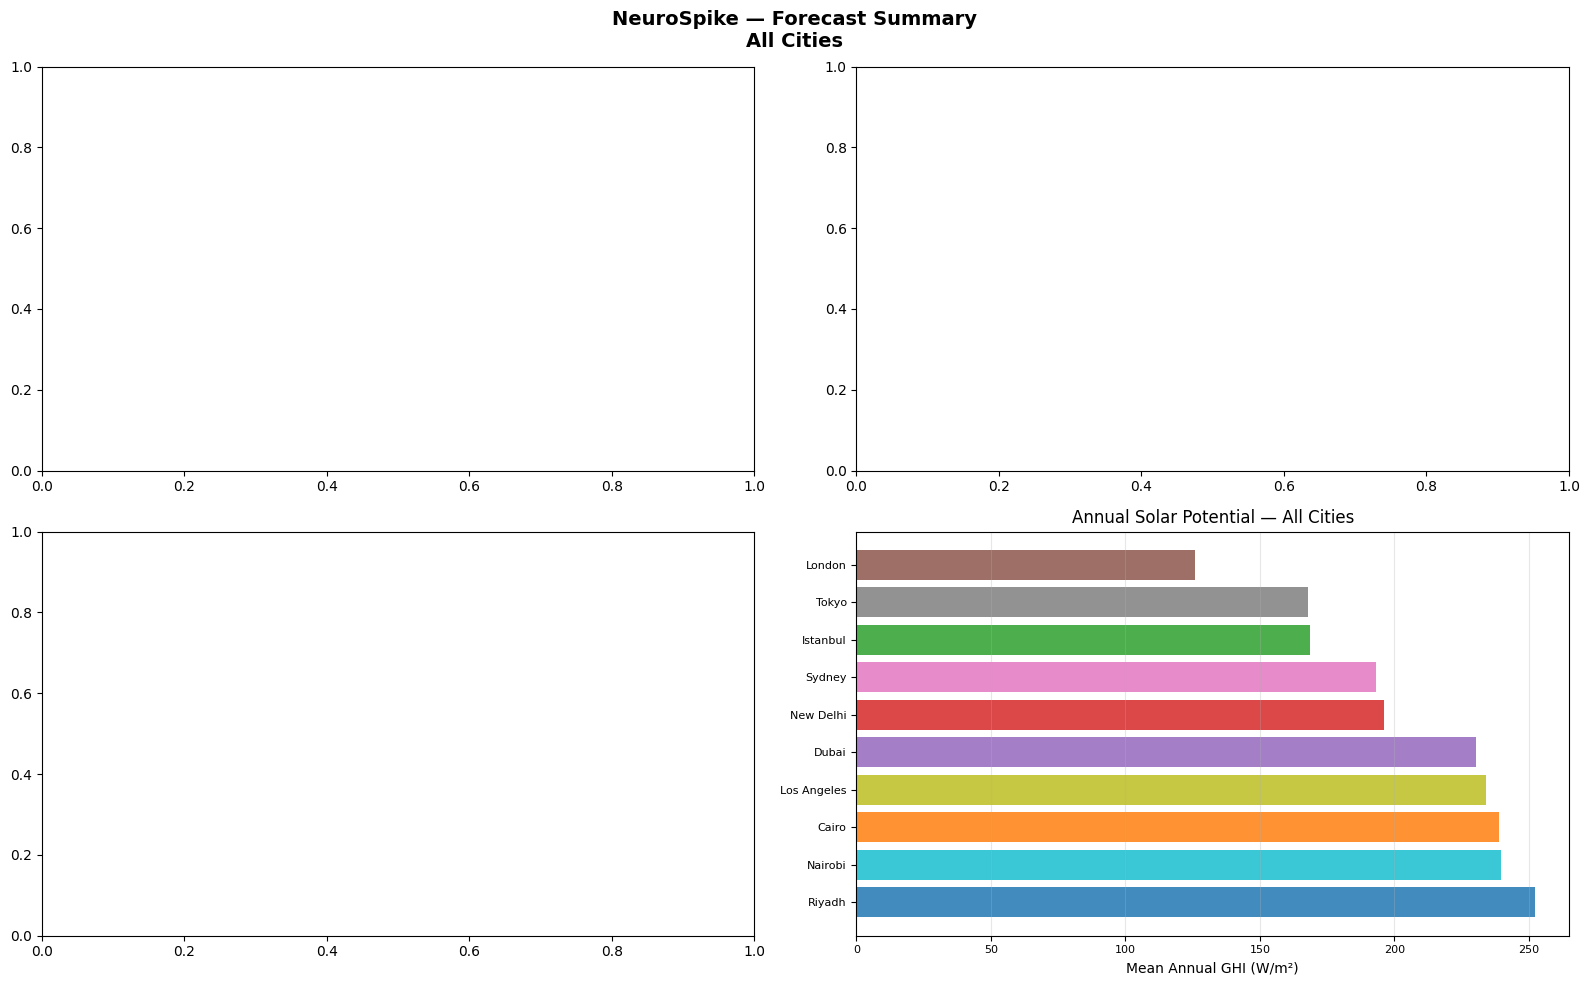

💾 Saved → ..\outputs/plots\10_forecast_summary.png


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(
    "NeuroSpike — Forecast Summary\nAll Cities",
    fontsize=14, fontweight="bold"
)

CITY_COLORS = dict(zip(
    CITIES, plt.cm.tab10(np.linspace(0, 1, len(CITIES)))
))

# ── h=1 GHI predictions ──────────────────────────────────────────
ax = axes[0, 0]
h1_ghis = []
for city in CITIES:
    if city not in all_forecasts:
        continue
    h1 = all_forecasts[city]["horizons"].get(1, {})
    if h1:
        h1_ghis.append((city, h1["ghi_wm2"][0]))

if h1_ghis:
    cities_plot, ghis_plot = zip(*sorted(
        h1_ghis, key=lambda x: x[1], reverse=True
    ))
    bars = ax.bar(
        [c.replace("_", "\n") for c in cities_plot],
        ghis_plot,
        color=[CITY_COLORS[c] for c in cities_plot],
        alpha=0.85
    )
    ax.set_ylabel("GHI (W/m²)")
    ax.set_title("Next-Hour GHI Forecast")
    ax.grid(True, alpha=0.3, axis="y")
    for bar, val in zip(bars, ghis_plot):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1,
            f"{val:.0f}", ha="center", fontsize=7
        )
    ax.tick_params(axis="x", labelsize=7)

# ── h=1 Power output ─────────────────────────────────────────────
ax = axes[0, 1]
if h1_ghis:
    powers_plot = [
        g * PANEL_EFFICIENCY * PANEL_AREA_M2
        for g in ghis_plot
    ]
    ax.bar(
        [c.replace("_", "\n") for c in cities_plot],
        powers_plot,
        color=[CITY_COLORS[c] for c in cities_plot],
        alpha=0.85
    )
    ax.set_ylabel("Power (W per panel)")
    ax.set_title("Next-Hour Power Output Estimate")
    ax.grid(True, alpha=0.3, axis="y")
    ax.tick_params(axis="x", labelsize=7)

# ── Multi-horizon for New Delhi ───────────────────────────────────
ax = axes[1, 0]
city = "new_delhi"
if city in all_forecasts:
    for horizon in HORIZONS:
        h_data = all_forecasts[city]["horizons"].get(horizon, {})
        if not h_data:
            continue
        steps  = list(range(1, len(h_data["ghi_wm2"]) + 1))
        ax.plot(
            steps, h_data["ghi_wm2"],
            marker="o", markersize=5,
            label=f"h={horizon}h",
            linewidth=2
        )
    ax.set_xlabel("Step ahead")
    ax.set_ylabel("GHI (W/m²)")
    ax.set_title(f"Multi-Horizon Forecast\n"
                 f"{city.replace('_',' ').title()}")
    ax.legend()
    ax.grid(True, alpha=0.3)

# ── Annual solar potential ────────────────────────────────────────
ax = axes[1, 1]
sorted_annual = sorted(annual_ghi.items(),
                         key=lambda x: x[1], reverse=True)
cities_ann, ghis_ann = zip(*sorted_annual)
ax.barh(
    [c.replace("_", " ").title() for c in cities_ann],
    ghis_ann,
    color=[CITY_COLORS[c] for c in cities_ann],
    alpha=0.85
)
ax.set_xlabel("Mean Annual GHI (W/m²)")
ax.set_title("Annual Solar Potential — All Cities")
ax.grid(True, alpha=0.3, axis="x")
ax.tick_params(labelsize=8)

plt.tight_layout()
path = os.path.join(PLOTS_DIR, "10_forecast_summary.png")
plt.savefig(path, dpi=120, bbox_inches="tight")
plt.show()
print(f"💾 Saved → {path}")

In [13]:
print("=" * 65)
print("  NOTEBOOK 10 — COMPLETE")
print("  NeuroSpike Project — ALL NOTEBOOKS DONE")
print("=" * 65)

print(f"\n  📁 Output files generated:")

all_outputs = []
for root, dirs, files in os.walk(
    os.path.join("..", "outputs")
):
    for f in files:
        full = os.path.join(root, f)
        size = os.path.getsize(full) / 1024
        all_outputs.append((full, size))

for path, size in sorted(all_outputs):
    print(f"     {path:<55} {size:>7.1f} KB")

print(f"\n  📁 Trained models:")
model_files = [
    f for f in os.listdir(MODELS_DIR)
    if f.endswith(".pt") or f.endswith(".keras")
    or f.endswith(".pkl")
]
print(f"     {len(model_files)} model files in {MODELS_DIR}")

print(f"""
  ╔══════════════════════════════════════════════════════╗
  ║         NeuroSpike Project Complete                  ║
  ║                                                      ║
  ║  Notebooks : 01 → 10  ✅                            ║
  ║  Cities    : 10 global locations                     ║
  ║  Models    : Baseline + BiLSTM + NeuroSpike SNN      ║
  ║  Horizons  : 1h, 6h, 24h ahead                      ║
  ║  Features  : 35+ engineered features                 ║
  ║  Data      : 3 years × 10 cities = 262,800 rows      ║
  ║                                                      ║
  ║  Next step : Run frontend/dashboard.py               ║
  ║  Command   : streamlit run frontend/dashboard.py     ║
  ╚══════════════════════════════════════════════════════╝
""")

  NOTEBOOK 10 — COMPLETE
  NeuroSpike Project — ALL NOTEBOOKS DONE

  📁 Output files generated:
     ..\outputs\forecasts\all_forecasts.json                     0.0 KB
     ..\outputs\forecasts\forecast_dashboard.html             4747.6 KB
     ..\outputs\forecasts\power_estimates.csv                    0.3 KB
     ..\outputs\metrics\baseline_results.csv                     3.2 KB
     ..\outputs\metrics\city_winners.csv                         0.4 KB
     ..\outputs\metrics\feature_scores.csv                       3.9 KB
     ..\outputs\metrics\final_summary_table.csv                  0.5 KB
     ..\outputs\metrics\lstm_cairo_h1_history.csv                3.3 KB
     ..\outputs\metrics\lstm_dubai_h1_history.csv                1.8 KB
     ..\outputs\metrics\lstm_istanbul_h1_history.csv             1.5 KB
     ..\outputs\metrics\lstm_london_h1_history.csv               1.8 KB
     ..\outputs\metrics\lstm_los_angeles_h1_history.csv          3.3 KB
     ..\outputs\metrics\lstm_nairobi_h1_